# Embedding Process

Questo notebook documenta il processo che porta dal dataset preprocessato agli embeddings numerici usati nelle prossime fasi di clustering.

La logica rimane nei moduli `src/utils`; qui vengono spiegati i passaggi, caricati gli output generati e verificata la coerenza degli embeddings.

## 1. Setup

Carichiamo path e configurazione da `.env`. Gli embeddings sono salvati in `data/embeddings`, mentre index e metadata restano in `data/metadata`.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import dotenv_values

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.embedding_pipeline import EmbeddingConfig, MODEL_REGISTRY, build_embedding_jobs

ENV_PATH = PROJECT_ROOT / ".env"
ENV = dotenv_values(ENV_PATH)

def project_path(env_key, default):
    value = Path(ENV.get(env_key, default))
    return value if value.is_absolute() else PROJECT_ROOT / value

CONFIG = EmbeddingConfig.from_env(ENV_PATH)
PROCESSED_PATH = CONFIG.processed_input_path
EMBEDDINGS_PATH = CONFIG.embeddings_output_path
EMBEDDING_INDEX_PATH = CONFIG.embedding_index_output_path
EMBEDDING_METADATA_PATH = CONFIG.embedding_metadata_output_path

FIGURES_ROOT = project_path("FIGURES_PATH", "reports/figures/")
FIGURES_PATH = FIGURES_ROOT / ENV.get("EMBEDDING_NOTEBOOK_FIGURES_SUBDIR", "embedding_process")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

EMBEDDING_NORMS_FIGURE = FIGURES_PATH / ENV.get("FIGURE_EMBEDDING_NORMS_FILENAME", "embedding_norms.png")
EMBEDDING_NORMS_DATA = FIGURES_PATH / ENV.get("FIGURE_EMBEDDING_NORMS_DATA_FILENAME", "embedding_norms.json")
EMBEDDING_CHUNKS_FIGURE = FIGURES_PATH / ENV.get("FIGURE_EMBEDDING_CHUNKS_FILENAME", "embedding_chunks.png")
EMBEDDING_CHUNKS_DATA = FIGURES_PATH / ENV.get("FIGURE_EMBEDDING_CHUNKS_DATA_FILENAME", "embedding_chunks.json")

plt.style.use("default")
pd.set_option("display.max_columns", 80)

/home/suga/Workspace/Projects/pizza-cluster/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Fase di pulizia usata come input

La pipeline embeddings non parte dal raw. Usa il processed sample creato dalla fase precedente:

- rimozione email promozionali;
- normalizzazione whitespace;
- creazione `combined_text`;
- preservazione delle censure, segnalate solo con `has_redaction`;
- feature grezze come lunghezze, allegati, destinatari stimati e date.

In [2]:
processed = pd.read_parquet(PROCESSED_PATH)
print(f"Processed input: {PROCESSED_PATH}")
print(f"Righe: {len(processed):,}")
print(f"Colonne: {processed.shape[1]}")
processed[["id", "combined_text_length", "has_redaction", "recipient_count_estimate"]].head()

Processed input: /home/suga/Workspace/Projects/pizza-cluster/data/processed/jmail_emails_processed_sample.parquet
Righe: 355
Colonne: 31


,id,combined_text_length,has_redaction,recipient_count_estimate
0,000fa4d83ae293b30ed3571c9ea2fd77,63,False,2
1,001612df62eb14194162f0a366793927,715,False,3
2,001df92b110e9da90631a66cf97a0a11,459,False,3
3,0036be5386133888b4201acacd0d6178,3916,False,3
4,0037a69505ae78dfacfebd97260f5325,1652,False,3


## 3. Feature engineering prima degli embeddings

La feature testuale primaria è `combined_text`. Prima dell'encoding viene trasformata in chunk, preservando il testo e i marker di censura.

La configurazione attuale controlla modello, lunghezza chunk, overlap e batch size.

In [3]:
config_summary = {
    "model_name": CONFIG.model_name,
    "model_info": MODEL_REGISTRY[CONFIG.model_name],
    "input_text_column": CONFIG.input_text_column,
    "chunk_char_length": CONFIG.chunk_char_length,
    "chunk_char_overlap": CONFIG.chunk_char_overlap,
    "batch_size": CONFIG.batch_size,
}
config_summary

{'model_name': 'BAAI/bge-small-en-v1.5',
 'model_info': {'embedding_dimensions': 384,
  'max_sequence_length': 512,
  'recommended_role': 'primary_baseline',
  'input_prefix': ''},
 'input_text_column': 'combined_text',
 'chunk_char_length': 1800,
 'chunk_char_overlap': 200,
 'batch_size': 32}

In [4]:
chunk_texts, planned_index = build_embedding_jobs(processed, CONFIG)
print(f"Chunk pianificati: {len(chunk_texts):,}")
planned_index[["id", "chunk_count", "embedding_text_length"]].describe()

Chunk pianificati: 545


,chunk_count,embedding_text_length
count,355.000000,355.000000
mean,1.535211,1519.692958
std,1.338595,2286.707850
min,1.000000,8.000000
25%,1.000000,286.500000
50%,1.000000,741.000000
75%,2.000000,1820.000000
max,11.000000,17505.000000


## 4. Creazione embeddings

Gli embeddings sono stati generati con il modello configurato in `.env`. Ogni email può produrre uno o più chunk; i chunk della stessa email vengono aggregati con media vettoriale e poi normalizzati.

Questo notebook non rigenera gli embeddings: carica gli output già prodotti dalla pipeline Python.

In [5]:
embeddings = np.load(EMBEDDINGS_PATH)
embedding_index = pd.read_parquet(EMBEDDING_INDEX_PATH)
with EMBEDDING_METADATA_PATH.open(encoding="utf-8") as file_handle:
    embedding_metadata = json.load(file_handle)

print(f"Embeddings path: {EMBEDDINGS_PATH}")
print(f"Shape: {embeddings.shape}")
embedding_metadata

Embeddings path: /home/suga/Workspace/Projects/pizza-cluster/data/embeddings/email_embeddings.npy
Shape: (355, 384)


{'created_at_utc': '2026-05-26T14:56:07.539858+00:00',
 'model_name': 'BAAI/bge-small-en-v1.5',
 'model_registry': {'embedding_dimensions': 384,
  'max_sequence_length': 512,
  'recommended_role': 'primary_baseline',
  'input_prefix': ''},
 'input_path': '/home/suga/Workspace/Projects/pizza-cluster/data/processed/jmail_emails_processed_sample.parquet',
 'embeddings_output_path': '/home/suga/Workspace/Projects/pizza-cluster/data/embeddings/email_embeddings.npy',
 'embedding_index_output_path': '/home/suga/Workspace/Projects/pizza-cluster/data/metadata/email_embedding_index.parquet',
 'row_count': 355,
 'embedding_dimensions': 384,
 'chunk_count': 545,
 'chunk_char_length': 1800,
 'chunk_char_overlap': 200,
 'batch_size': 32,
 'normalization': 'L2 row normalization after mean chunk aggregation.'}

## 5. Controlli di coerenza

Verifichiamo che il numero di vettori coincida con il numero di email processate, che le dimensioni siano quelle previste dal modello e che non ci siano righe senza chunk.

In [6]:
expected_dimensions = MODEL_REGISTRY[CONFIG.model_name]["embedding_dimensions"]
norms = np.linalg.norm(embeddings, axis=1)

assert embeddings.shape[0] == len(processed)
assert embeddings.shape[0] == len(embedding_index)
assert embeddings.shape[1] == expected_dimensions
assert int((embedding_index["chunk_count"] == 0).sum()) == 0

summary = {
    "embedding_rows": int(embeddings.shape[0]),
    "embedding_dimensions": int(embeddings.shape[1]),
    "chunk_count": int(embedding_index["chunk_count"].sum()),
    "norm_min": float(norms.min()),
    "norm_mean": float(norms.mean()),
    "norm_max": float(norms.max()),
}
summary

{'embedding_rows': 355,
 'embedding_dimensions': 384,
 'chunk_count': 545,
 'norm_min': 0.9999998807907104,
 'norm_mean': 1.0,
 'norm_max': 1.0000001192092896}

## 6. Grafici diagnostici

I grafici controllano distribuzione delle norme e numero di chunk per email. Ogni figura viene salvata insieme a un JSON con i dati numerici per ricreare il grafico fuori dal notebook.

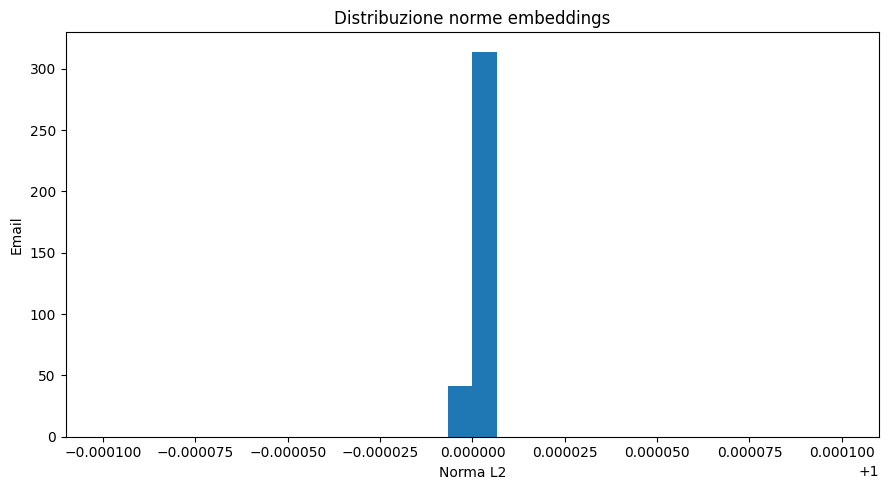

In [7]:
norms_fig, ax = plt.subplots(figsize=(9, 5))
norm_min, norm_max = float(norms.min()), float(norms.max())
norm_margin = max(1e-4, (norm_max - norm_min) * 0.1)
ax.hist(norms, bins=30, range=(norm_min - norm_margin, norm_max + norm_margin))
ax.set_title("Distribuzione norme embeddings")
ax.set_xlabel("Norma L2")
ax.set_ylabel("Email")
norms_fig.tight_layout()
plt.show()

In [8]:
norm_payload = {
    "title": "Distribuzione norme embeddings",
    "x_label": "Norma L2",
    "y_label": "Email",
    "values": norms.tolist(),
    "summary": summary,
}
EMBEDDING_NORMS_DATA.write_text(json.dumps(norm_payload, indent=2, ensure_ascii=False), encoding="utf-8")
norms_fig.savefig(EMBEDDING_NORMS_FIGURE, dpi=160, bbox_inches="tight")
print(f"Figura salvata in: {EMBEDDING_NORMS_FIGURE}")
print(f"Dati figura salvati in: {EMBEDDING_NORMS_DATA}")

Figura salvata in: /home/suga/Workspace/Projects/pizza-cluster/reports/figures/embedding_process/embedding_norms.png
Dati figura salvati in: /home/suga/Workspace/Projects/pizza-cluster/reports/figures/embedding_process/embedding_norms.json


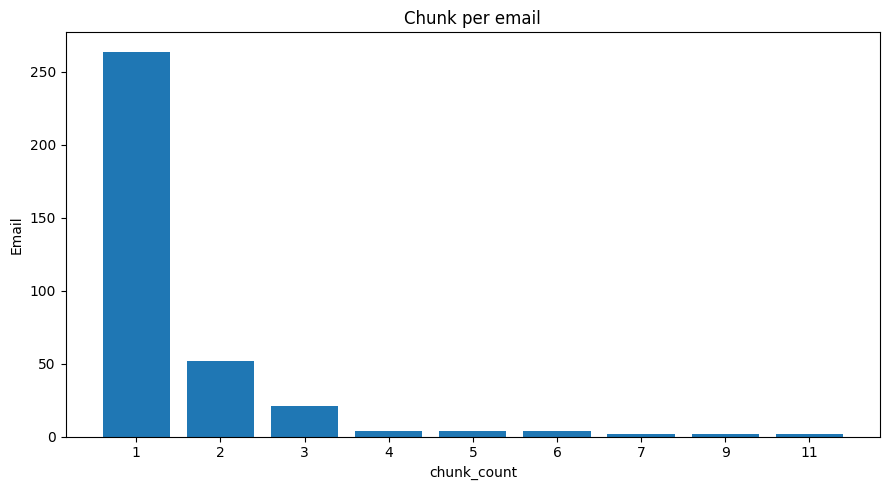

In [9]:
chunk_counts = embedding_index["chunk_count"].value_counts().sort_index()
chunks_fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(chunk_counts.index.astype(str), chunk_counts.values)
ax.set_title("Chunk per email")
ax.set_xlabel("chunk_count")
ax.set_ylabel("Email")
chunks_fig.tight_layout()
plt.show()

In [10]:
chunks_payload = {
    "title": "Chunk per email",
    "x_label": "chunk_count",
    "y_label": "Email",
    "data": chunk_counts.rename_axis("chunk_count").reset_index(name="count").to_dict(orient="records"),
}
EMBEDDING_CHUNKS_DATA.write_text(json.dumps(chunks_payload, indent=2, ensure_ascii=False), encoding="utf-8")
chunks_fig.savefig(EMBEDDING_CHUNKS_FIGURE, dpi=160, bbox_inches="tight")
print(f"Figura salvata in: {EMBEDDING_CHUNKS_FIGURE}")
print(f"Dati figura salvati in: {EMBEDDING_CHUNKS_DATA}")

Figura salvata in: /home/suga/Workspace/Projects/pizza-cluster/reports/figures/embedding_process/embedding_chunks.png
Dati figura salvati in: /home/suga/Workspace/Projects/pizza-cluster/reports/figures/embedding_process/embedding_chunks.json


## 7. Conclusione

La pipeline embeddings produce un vettore per ogni email processata. I vettori sono normalizzati e allineati tramite `email_embedding_index.parquet`, che permette di ricostruire la relazione tra email, chunk e riga dell'array `.npy`.

Il prossimo passaggio naturale è usare questi vettori per prime prove di clustering e visualizzazione.